## Experiment: Linear Regression over ill-conditioned data
Syntetic data are used to illustrate the behavior of linear regression when applied to ill-conditioned data. The dataset consists of a set of input features and corresponding target values, where the features are highly correlated, leading to multicollinearity issues.

In [ ]:
import numpy as np
from myst_nb import glue

# Configuration
EPS = 1e-3
NOISE = 2
EPOCHS = 35
DATASET_SIZE = 100

In [2]:
# Function to estimate
def f(x: np.ndarray) -> np.ndarray:
    return x*2 + 2

In [3]:
# Dataset
from core.dataset.dataset import TensorDataset
from core.tensor import Tensor

x = np.linspace(-5, 5, DATASET_SIZE)
y = x + EPS * np.random.randn(DATASET_SIZE)
X = np.stack([x, y]).T
y = f(X)
dataset_tr, dataset_te = TensorDataset(Tensor(X), Tensor(y)).split()
X_tr, y_tr = dataset_tr
X_te, y_te = dataset_te

y_tr += np.random.uniform(-1, 1, y_tr.shape)*NOISE
y_te += np.random.uniform(-1, 1, y_te.shape)*NOISE

print(f'X.shape: {X.shape}, y.shape: {y.shape}')
print(f'X_tr.shape: {X_tr.shape}, y_tr.shape: {y_tr.shape}')
print(f'X_te.shape: {X_te.shape}, y_te.shape: {y_te.shape}')
print(f'condition number: k(X) = {np.linalg.cond(X)}')

X.shape: (100, 2), y.shape: (100, 2)
X_tr.shape: (90, 2), y_tr.shape: (90, 2)
X_te.shape: (10, 2), y_te.shape: (10, 2)
condition number: k(X) = 6043.784799253357


## Dataset 
The dataset is generated using a linear model with added noise. The input features are created to be highly correlated, which can cause instability in the estimation of regression coefficients. The target variable is generated as a linear combination of the input features plus some random noise.

The dataset is split into training and testing sets to evaluate the performance of the linear regression model.
The training set is 95% of data meanwhile the test set is 5%

In [4]:
from core.optimizer import SGD
from core.losses import MSELoss
from core.layers import Linear, Sequential

LR = 1e-4

# Linear Regression
model = Sequential(
    Linear(2, 2)
)
loss = MSELoss()
optimizer = SGD(model.parameters, LR)

In [5]:
# Training loop
LR = 1e-4
TEST_STEP = 5

assert(EPOCHS % TEST_STEP == 0)
train_losses:list[float] = []
test_losses:list[float] = []

for i in range(EPOCHS):
    pred = model(X_tr)
    train_loss = loss(pred, y_tr)
    train_losses.append(train_loss.data)
    
    if i % TEST_STEP == 0 or i == EPOCHS-1:
        model.eval()
        pred_test = model(X_te)
        test_loss = loss(pred_test, y_te)
        test_losses.append(test_loss.data)
        model.train()

    train_loss.backward()
    optimizer.step()
    

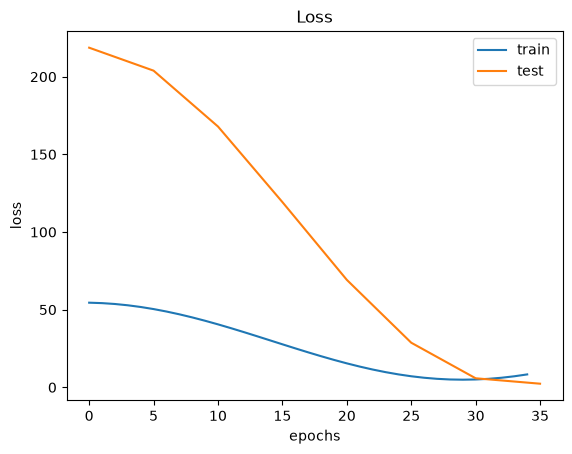

In [6]:
import matplotlib.pyplot as plt

# Loss section
plt.plot(list(range(EPOCHS)), train_losses, label='train')
plt.plot(list(range(0, EPOCHS+1, TEST_STEP)), test_losses, label='test')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

plt.show()

In [26]:
# Closed form solution
from core.functions import mse


A = np.hstack([X_te.data, np.ones((X_te.shape[0], 1))])
coefs, *_ = np.linalg.lstsq(A, y_te.data, rcond=None)
closed_form = A @ coefs

# Prediction
pred = model(X_te)
W_model, b_model = model.parameters[:]
W_model, b_model = W_model.data, b_model.data.reshape(-1, 1)
params = np.hstack([W_model, b_model]).T

pred_residual = mse(pred.data, closed_form)
weights_residual = mse(params, coefs)

print(f'prediction residual: {pred_residual}')
print(f'weights resididual: {weights_residual}\n')
print(f'model params: {params}\n')
print(f'closed form coefficent: {coefs}')

prediction residual: 1.8900999662704367
weights resididual: 104889.59286854137

model params: [[0.9811784  1.7453182 ]
 [1.0948545  1.5018415 ]
 [0.10528515 0.13193755]]

closed form coefficent: [[-472.43098364  303.05321449]
 [ 472.89228356 -301.39194315]
 [   9.3758887     3.06973796]]
